# Tennis Court Detector

Del notebook anterior, obtuvimos una función que es capaz de detectar a jugadores y pelota por frame. El problema es que también es capaz de detectar pelotas y personas fuera de la cancha:

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import torch.nn as nn
import torch.optim as optim
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import glob
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.patches as patches
import json
import time
from tqdm import tqdm
from collections import defaultdict


In [29]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Versión de CUDA en PyTorch: {torch.version.cuda}")

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Número de GPUs detectadas: {num_gpus}")
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        # capacidad de cómputo
        capability = torch.cuda.get_device_capability(i)
        print(f"  Capacidad de cómputo: {capability[0]}.{capability[1]}")
else:
    print("No se detectaron GPUs con soporte CUDA.")

PyTorch version: 2.5.1+cu121
CUDA disponible: True
Versión de CUDA en PyTorch: 12.1
Número de GPUs detectadas: 1
  GPU 0: NVIDIA GeForce RTX 3070 Ti Laptop GPU
  Capacidad de cómputo: 8.6


In [ ]:
# Paleta de colores por player_id (BGR)
_PLAYER_COLORS = [
    (255, 100, 0), (0, 200, 255), (0, 255, 100),
    (200, 0, 255), (255, 200, 0), (0, 100, 255),
]

def _draw_frame(
    frame: np.ndarray,
    ball_result,
    players_result,
) -> np.ndarray:
    """Dibuja detecciones de pelota y jugadores sobre el frame."""
    out = frame.copy()
    _draw_ball(out, ball_result)
    _draw_players(out, players_result)
    return out


def _draw_ball(frame: np.ndarray, r) -> None:
    """Dibuja bbox de la pelota (amarillo)."""
    if r.boxes is None or len(r.boxes) == 0:
        return

    confs  = r.boxes.conf.tolist()
    bboxes = r.boxes.xyxy.tolist()
    best   = int(pd.Series(confs).idxmax())
    x1, y1, x2, y2 = [int(v) for v in bboxes[best]]

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 2)
    cv2.putText(
        frame, f"ball {confs[best]:.2f}",
        (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1,
    )


def _draw_players(frame: np.ndarray, r) -> None:
    """Dibuja bbox y player_id por jugador (color único por ID)."""
    if r.boxes is None or r.boxes.id is None:
        return

    ids    = r.boxes.id.int().tolist()
    confs  = r.boxes.conf.tolist()
    bboxes = r.boxes.xyxy.tolist()

    for pid, conf, (x1, y1, x2, y2) in zip(ids, confs, bboxes):
        color = _PLAYER_COLORS[pid % len(_PLAYER_COLORS)]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            frame, f"P{pid} {conf:.2f}",
            (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2,
        )

In [ ]:
def visualize_frame(
    image_path: str,
    ball_model_path: str,
    players_model_path: str,
    conf: float = 0.35,
    imgsz: int = 640,
    device: int | str = 0,
    figsize: tuple[int, int] = (14, 8),
) -> None:
    """
    Visualiza las detecciones de pelota y tracking de jugadores sobre una imagen
    estática, renderizando el resultado inline en un Jupyter Notebook.

    Parameters
    ----------
    image_path : str
        Ruta a la imagen de entrada (.jpg, .png, etc).
    ball_model_path : str
        Ruta al modelo YOLO de pelota.
    players_model_path : str
        Ruta al modelo YOLO de jugadores.
    conf : float
        Umbral de confianza para ambos modelos.
    imgsz : int
        Tamaño de imagen para inferencia.
    device : int | str
        Dispositivo de inferencia.
    figsize : tuple[int, int]
        Tamaño de la figura matplotlib (ancho, alto) en pulgadas.
    """
    ball_model    = YOLO(ball_model_path)
    players_model = YOLO(players_model_path)

    frame = cv2.imread(image_path)
    if frame is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {image_path}")

    #  Inferencia 
    ball_result    = ball_model.predict(
        frame, conf=conf, imgsz=imgsz, device=device, verbose=False
    )[0]
    players_result = players_model.track(
        frame, conf=conf, imgsz=imgsz, device=device, verbose=False, persist=False, classes=[0] #only persons detected
    )[0]

    #  Anotación (reutiliza helpers de perception_layer) 
    annotated_bgr = _draw_frame(frame, ball_result, players_result)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    #  Stats para el título 
    n_players  = len(players_result.boxes.id) if players_result.boxes.id is not None else 0
    ball_found = ball_result.boxes is not None and len(ball_result.boxes) > 0

    title = f"Jugadores detectados: {n_players}  |  Pelota: {'✓' if ball_found else '✗'}  |  conf ≥ {conf}"

    #  Render inline 
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(annotated_rgb)
    ax.set_title(title, fontsize=12, pad=10)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
ruta_mejor_modelo_deteccion_pelota = "../runs/detect/train3/weights/best.pt"
ruta_mejor_modelo_tracking_jugadores = "./yolo26x.pt"

visualize_frame(
    image_path        = "../data/tennis_match.jpg",
    ball_model_path   = ruta_mejor_modelo_deteccion_pelota,
    players_model_path= ruta_mejor_modelo_tracking_jugadores
)

Para solucionar esto es necesario agregar un modelo que delimite la cancha, a través de la detección de puntos clave. En este notebook se construirá el **TennisCourtDetector**

```bash
# Antes (actual)
video -> frame_loop -> [YOLO_ball]    -> detecciones  ─┐
                   -> [YOLO_players] -> tracks        ─┤-> draw -> frame_out -> video
                                                      |
                                                      v
                                                  DataFrame (igual que antes)
# Ahora
video -> frame_loop ->[TennisCourtDetector] -> [YOLO_ball]    -> detecciones  ─┐
                                          -> [YOLO_players] -> tracks        ─┤-> draw -> frame_out -> video
                                                                              |
                                                                              v
                                                                        DataFrame (igual que antes)
```

## Download Data

- Se puede obtener la data desde `https://drive.google.com/file/d/1lhAaeQCmk2y440PmagA0KmIVBIysVMwu/view`
- El repositorio del proyecto original es `https://github.com/yastrebksv/TennisCourtDetector`

In [ ]:
def get_average_image_size(img_dir):
    extensions = ['*.jpg', '*.jpeg', '*.png']
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(img_dir, ext)))

    if not image_paths:
        print(f"No se encontraron imágenes en: {img_dir}")
        return None

    widths = []
    heights = []

    print(f"Procesando {len(image_paths)} imágenes...")

    # 2. Iterar y extraer dimensiones
    for path in image_paths:
        # Usamos imread, pero podrías usar os.stat si solo quieres el tamaño en bytes
        # Para dimensiones reales de píxeles, OpenCV es lo más directo
        # Reemplaza el bloque de lectura por:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

    # 3. Calcular métricas
    avg_w = np.mean(widths)
    avg_h = np.mean(heights)
    std_w = np.std(widths)
    std_h = np.std(heights)

    print("-" * 30)
    print(f"Resultados para: {os.path.basename(img_dir)}")
    print(f"Ancho promedio: {avg_w:.2f} px (std: {std_w:.2f})")
    print(f"Alto promedio:  {avg_h:.2f} px (std: {std_h:.2f})")
    print(f"Relación de aspecto promedio: {avg_w/avg_h:.2f}")
    print("-" * 30)

    return {"avg_w": avg_w, "avg_h": avg_h, "count": len(widths)}

- El dataset contiene un directorio **imagenes** con 8842 imágenes de canchas de tenis mirando siempre desde la misma dirección.
- data_train.json es una lista que contiene objetos json con la sgte estructura:

        ```bash
        [
            {
                "id":string,
                "metric":float,
                "kps":[
                    [int, int], #coordenada x, y para cada punto 
                    ....
                    [int, int]
                ]
            }, ...
        ]
        ```
- **id** es el nombre de la imagen
- **metric** es la fracción del área de la imagen ocupada por la cancha (esquinas 0, 1, 2, 3), valor típico ~0.30 significa que la cancha ocupa aprox el 30% del frame.
- **kps** contiene 14 arrays, cada uno con dos números enteros que representan las coordenadas x e y respectivamente de cada uno de los puntos clave de la cancha de tenis. Cada imagen es de 1280 px de ancho y 720 px de alto. Las coordenadas aparecen en px. 

In [ ]:
images_path = "../data/tennis_court_key_points/images/"
data_train_json_path = "../data/tennis_court_key_points/data_train.json"
get_average_image_size(images_path)

In [ ]:
def visualize_keypoints(image_id, data_path, images_path):
    """
    Visualiza una imagen de cancha de tenis con sus keypoints numerados.
    
    Args:
        image_id: string con el id de la imagen (sin extensión)
        data_path: ruta al archivo JSON con las anotaciones
        images_path: ruta a la carpeta de imágenes
    """
    # Cargar JSON
    with open(data_path, 'r') as f:
        data = json.load(f)
    
    # Buscar el entry correspondiente al id
    entry = next((d for d in data if d['id'] == image_id), None)
    if entry is None:
        raise ValueError(f"No se encontró imagen con id '{image_id}' en el JSON.")
    
    kps = entry['kps']  # lista de [x, y]
    
    # Leer imagen con OpenCV y convertir BGR -> RGB para matplotlib
    img_path = os.path.join(images_path, image_id + '.png')
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen en: {img_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(img_rgb)
    
    color = 'cyan'
    
    for i, (x, y) in enumerate(kps):
        # Círculo en el punto
        circle = plt.Circle((x, y), radius=10, color=color, linewidth=1.5, fill=True, alpha=0.85)
        ax.add_patch(circle)
        
        # Número encima del punto
        ax.text(
            x, y - 16,
            str(i),
            color='white',
            fontsize=9,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6, edgecolor='none')
        )
    
    ax.set_title(f"Image: {image_id}  |  Keypoints: {len(kps)}", fontsize=13, pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# En la imagen los puntos se muestran numerados (desde 0) en el mismo orden en que están guardados en el array kps
visualize_keypoints(image_id="PuXlxKdUIes_2450", data_path=data_train_json_path, images_path=images_path)

In [ ]:
with open(data_train_json_path) as f:
    data = json.load(f)

metrics = [d['metric'] for d in data]
print(f"Min:    {min(metrics):.4f}")
print(f"Max:    {max(metrics):.4f}")
print(f"Mean:   {np.mean(metrics):.4f}")
print(f"Std:    {np.std(metrics):.4f}")
print(f"Sample: {metrics[:10]}")

In [ ]:
entry = data[0]
kps = np.array(entry['kps'])

# Esquinas exteriores: 0 (top-left), 1 (top-right), 2 (bottom-left), 3 (bottom-right)
# cv2.contourArea necesita orden: top-left, top-right, bottom-right, bottom-left
corners = kps[[0, 1, 3, 2]].astype(np.float32)  # reordenado en sentido horario
area_corners = cv2.contourArea(corners)
area_img = 1280 * 720

ratio = area_corners / area_img
print(f"Ratio con 4 esquinas reordenadas: {ratio:.4f}")
print(f"Metric en JSON:                   {entry['metric']:.4f}")

**metric** puede ser útil como:

- Filtro de calidad: imágenes con metric muy bajo -> cancha muy pequeña/lejana, más difícil de predecir keypoints
- Peso en el loss: darle más peso a imágenes donde la cancha es grande y los keypoints son más precisos
- Stratified sampling: balancear el entrenamiento por tamaño de cancha

---

# Entrenamiento

In [30]:
def compute_dataset_stats(img_dir: str, data_file: str, sample_size: int = 2000) -> tuple:
    """
    Computes mean and std from a sample of the dataset.
    Run this once and hardcode the results into KeyPointsDataset.
    """
    with open(data_file, 'r') as f:
        data = json.load(f)

    basic_transforms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    indices = torch.randperm(len(data))[:sample_size]
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0

    for idx in tqdm(indices, desc="Computing stats"):
        item = data[idx]
        img = cv2.imread(f"{img_dir}/{item['id']}.png")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = basic_transforms(img)  # [C, H, W]
        channels_sum += img.mean(dim=[1, 2])
        channels_squared_sum += (img ** 2).mean(dim=[1, 2])
        num_batches += 1

    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5
    return mean.tolist(), std.tolist()

In [ ]:
#mean, std = compute_dataset_stats(img_dir='../data/tennis_court_key_points/images', data_file='../data/tennis_court_key_points/data_train.json', sample_size= 8841)
#print(mean)
#print(std)

In [31]:
class KeyPointsDataset(Dataset):
    # For another model
    #MEAN = [0.3717651665210724, 0.3994114100933075, 0.4226387143135071]
    #STD = [0.17913301289081573, 0.165054053068161, 0.1837901920080185]
    # For resnet
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_dir: str, data_file: str):
        self.img_dir = img_dir
        with open(data_file, 'r') as f:
            self.data = json.load(f)

        self.transforms = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=self.MEAN, std=self.STD),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = cv2.imread(f"{self.img_dir}/{item['id']}.png")
        h, w = img.shape[:2]

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transforms(img)

        kps = np.array(item['kps']).flatten().astype(np.float32)
        kps[::2]  *= 224.0 / w
        kps[1::2] *= 224.0 / h
        return img, kps

In [32]:
img_dir = '../data/tennis_court_key_points/images'
data_file = '../data/tennis_court_key_points/data_val.json'

# Training set
train_dataset = KeyPointsDataset(
    img_dir = img_dir,
    data_file = data_file
)

# Validation / test set
val_dataset = KeyPointsDataset(
    img_dir = img_dir,
    data_file = data_file
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True       # faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Check a batch
imgs, kps = next(iter(train_loader))
print(f"Images shape: {imgs.shape}")   # [32, 3, 224, 224]
print(f"Keypoints shape: {kps.shape}") # [32, num_kps * 2]

Images shape: torch.Size([8, 3, 224, 224])
Keypoints shape: torch.Size([8, 28])


In [33]:
model = models.resnet50(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features, 14*2) #14 key points with x, y. Replace the last layer
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

c:\Users\sprou\Documents\tennis-data-analysis-engine\venv_tennis_data_analysis\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sprou\Documents\tennis-data-analysis-engine\venv_tennis_data_analysis\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [41]:
#  Constants 
CHECKPOINT_DIR   = "checkpoints"
SAVE_EVERY_N     = 5        # also save every N epochs
PCK_THRESHOLD    = 0.05     # fraction of image size (224px -> 22.4px tolerance)
EARLY_STOP_PAT   = 10       # stop if no improvement for this many epochs
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [35]:
#  Metrics 

def compute_mae(preds: np.ndarray, targets: np.ndarray) -> float:
    """Mean Absolute Error across all keypoints (in pixels)."""
    return np.abs(preds - targets).mean()


def compute_pck(preds: np.ndarray, targets: np.ndarray,
                img_size: int = 224, threshold: float = PCK_THRESHOLD) -> float:
    """
    Percentage of Correct Keypoints.
    A keypoint is 'correct' if its Euclidean distance to the GT
    is within threshold * img_size pixels.
    preds/targets shape: [N, num_kps*2]
    """
    tolerance = threshold * img_size

    # Reshape to [N, num_kps, 2]
    p = preds.reshape(len(preds), -1, 2)
    t = targets.reshape(len(targets), -1, 2)

    distances = np.sqrt(((p - t) ** 2).sum(axis=-1))  # [N, num_kps]
    return (distances < tolerance).mean() * 100        # percentage

In [37]:
#  Checkpoint helpers 

def save_checkpoint(model, optimizer, epoch, metrics, path):
    torch.save({
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "metrics":    metrics,
    }, path)
    print(f"  → Checkpoint saved: {path}")


def load_checkpoint(path, model, optimizer=None):
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    if optimizer:
        optimizer.load_state_dict(ckpt["optimizer"])
    print(f"Loaded checkpoint from epoch {ckpt['epoch']}  |  {ckpt['metrics']}")
    return ckpt["epoch"], ckpt["metrics"]

In [38]:
#  Evaluation 

def evaluate(model, loader, loss_fn, device):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0.0

    with torch.no_grad():
        for imgs, kps in loader:
            imgs = imgs.to(device)
            kps  = kps.to(device)
            out  = model(imgs)
            total_loss += loss_fn(out, kps).item()
            all_preds.append(out.cpu().numpy())
            all_targets.append(kps.cpu().numpy())

    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    return {
        "loss": total_loss / len(loader),
        "mae":  compute_mae(preds, targets),
        "pck":  compute_pck(preds, targets),
    }

In [39]:
#  Visualization 

def plot_history(history: dict):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # MAE
    axes[1].plot(epochs, history["val_mae"], color="orange")
    axes[1].set_title("Val MAE (px)")
    axes[1].set_xlabel("Epoch")

    # PCK
    axes[2].plot(epochs, history["val_pck"], color="green")
    axes[2].set_title(f"Val PCK@{PCK_THRESHOLD} (%)")
    axes[2].set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

In [ ]:
# lossFunction = torch.nn.MSELoss()
# optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)
# epochs=2
# for epoch in range(epochs):
#     for i, (img, kps) in enumerate(train_loader):
#         img = img.to(device)
#         kps = kps.to(device)

#         optimizer.zero_grad()
#         outputs = model(img)
#         loss = lossFunction(outputs, kps)
#         loss.backward()
#         optimizer.step()

#         if i % 10 == 0: 
#             print(f'Epoch {epoch}, iter {i}, loss:{loss.item()}')

def train(model, train_loader, val_loader, optimizer, loss_fn, device, epochs):
    history     = defaultdict(list)
    best_val    = float("inf")
    no_improve  = 0                  # early stopping counter

    for epoch in range(1, epochs + 1):
        #  Train 
        model.train()
        train_loss = 0.0
        for i, (imgs, kps) in enumerate(train_loader):
            imgs = imgs.to(device)
            kps  = kps.to(device)

            optimizer.zero_grad()
            loss = loss_fn(model(imgs), kps)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            if i % 10 == 0:
                print(f"  Epoch {epoch}/{epochs}  iter {i}  loss: {loss.item():.4f}")

        train_loss /= len(train_loader)

        #  Validate 
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        print(f"\nEpoch {epoch}/{epochs} "
              f"| train_loss: {train_loss:.4f} "
              f"| val_loss: {val_metrics['loss']:.4f} "
              f"| val_mae: {val_metrics['mae']:.2f}px "
              f"| val_pck: {val_metrics['pck']:.1f}%\n")

        #  History 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_pck"].append(val_metrics["pck"])

        #  Checkpoint: every N epochs 
        if epoch % SAVE_EVERY_N == 0:
            save_checkpoint(model, optimizer, epoch, val_metrics,
                            f"{CHECKPOINT_DIR}/epoch_{epoch:03d}.pth")

        #  Checkpoint: best model 
        if val_metrics["loss"] < best_val:
            best_val   = val_metrics["loss"]
            no_improve = 0
            save_checkpoint(model, optimizer, epoch, val_metrics,
                            f"{CHECKPOINT_DIR}/best.pth")
        else:
            no_improve += 1
            print(f"  No improvement for {no_improve}/{EARLY_STOP_PAT} epochs.")
            if no_improve >= EARLY_STOP_PAT:
                print("Early stopping triggered.")
                break
    return history

  Epoch 1/5  iter 0  loss: 14651.4219
  Epoch 1/5  iter 10  loss: 14970.5703
  Epoch 1/5  iter 20  loss: 14120.2197
  Epoch 1/5  iter 30  loss: 13812.9229
  Epoch 1/5  iter 40  loss: 13342.3809
  Epoch 1/5  iter 50  loss: 13194.3545
  Epoch 1/5  iter 60  loss: 12634.1436
  Epoch 1/5  iter 70  loss: 12116.4512
  Epoch 1/5  iter 80  loss: 11556.9336
  Epoch 1/5  iter 90  loss: 11543.2295
  Epoch 1/5  iter 100  loss: 10951.1787
  Epoch 1/5  iter 110  loss: 10772.2012
  Epoch 1/5  iter 120  loss: 10479.9727
  Epoch 1/5  iter 130  loss: 10330.8662
  Epoch 1/5  iter 140  loss: 10862.6592
  Epoch 1/5  iter 150  loss: 9956.2168
  Epoch 1/5  iter 160  loss: 8721.7607
  Epoch 1/5  iter 170  loss: 10541.5762
  Epoch 1/5  iter 180  loss: 8740.4336
  Epoch 1/5  iter 190  loss: 8228.0293
  Epoch 1/5  iter 200  loss: 7746.6182
  Epoch 1/5  iter 210  loss: 7214.0557
  Epoch 1/5  iter 220  loss: 6762.8862
  Epoch 1/5  iter 230  loss: 8563.1406
  Epoch 1/5  iter 240  loss: 6315.6118
  Epoch 1/5  iter 25

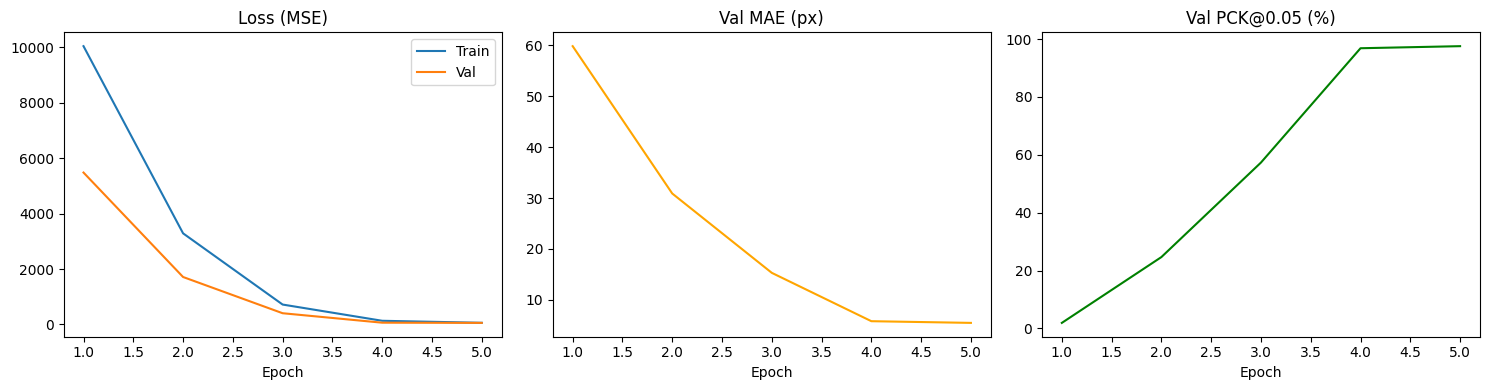

In [42]:
#  Run 

loss_fn   = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

history = train(
    model, train_loader, val_loader,
    optimizer, loss_fn, device,
    epochs=5
)

In [44]:
torch.save(model.state_dict(), "keypoints_model.pth")

# Retraining the best model

C:\Users\sprou\AppData\Local\Temp\ipykernel_20772\3465220934.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")


Loaded checkpoint from epoch 5  |  {'loss': 57.8744049347695, 'mae': np.float32(5.4812474), 'pck': np.float64(97.56089681462817)}
Resuming from epoch 5 | val_loss: 57.8744
  Epoch 1/100  iter 0  loss: 106.3947
  Epoch 1/100  iter 10  loss: 43.4193
  Epoch 1/100  iter 20  loss: 40.1117
  Epoch 1/100  iter 30  loss: 23.9112
  Epoch 1/100  iter 40  loss: 34.8298
  Epoch 1/100  iter 50  loss: 24.3204
  Epoch 1/100  iter 60  loss: 29.5634
  Epoch 1/100  iter 70  loss: 67.1857
  Epoch 1/100  iter 80  loss: 33.3605
  Epoch 1/100  iter 90  loss: 43.9748
  Epoch 1/100  iter 100  loss: 47.6840
  Epoch 1/100  iter 110  loss: 176.0097
  Epoch 1/100  iter 120  loss: 52.2482
  Epoch 1/100  iter 130  loss: 50.2974
  Epoch 1/100  iter 140  loss: 34.3709
  Epoch 1/100  iter 150  loss: 32.7166
  Epoch 1/100  iter 160  loss: 25.8999
  Epoch 1/100  iter 170  loss: 43.4781
  Epoch 1/100  iter 180  loss: 31.8692
  Epoch 1/100  iter 190  loss: 30.1270
  Epoch 1/100  iter 200  loss: 21.0062
  Epoch 1/100  ite

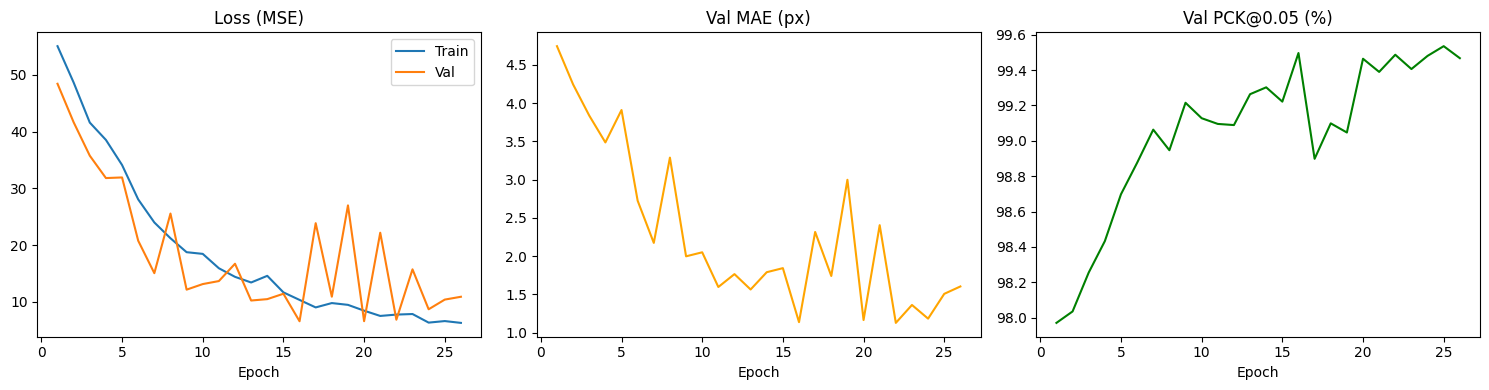

In [51]:
# Load best model
model = models.resnet50()
model.fc = torch.nn.Linear(model.fc.in_features, 14 * 2)
model = model.to(device)

loss_fn   = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Load weights AND optimizer state
epoch_start, metrics = load_checkpoint("checkpoints/best.pth", model, optimizer)
print(f"Resuming from epoch {epoch_start} | val_loss: {metrics['loss']:.4f}")

# Continue training
history = train(
    model, train_loader, val_loader,
    optimizer, loss_fn, device,
    epochs=100   # additional epochs
)

---

# Predict on images and videos

In [45]:
def predict_image(model, image_path: str, device: torch.device) -> tuple:
    """
    Predicts keypoints for a single image.
    Returns the annotated image (numpy) and the keypoints array.
    """
    transforms_pipeline = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    input_tensor = transforms_pipeline(img_rgb).unsqueeze(0).to(device)  # [1, 3, 224, 224]

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)                   # [1, 28]

    kps = output.squeeze().cpu().numpy()               # [28]

    # Scale keypoints back to original image size
    kps[::2]  *= w / 224.0
    kps[1::2] *= h / 224.0

    # Draw keypoints on original image
    annotated = img.copy()
    for i in range(0, len(kps), 2):
        x, y = int(kps[i]), int(kps[i + 1])
        cv2.circle(annotated, (x, y), radius=5, color=(0, 255, 0), thickness=-1)

    return annotated, kps


def predict_video(model, video_path: str, output_path: str, device: torch.device) -> None:
    """
    Predicts keypoints for every frame in a video and saves annotated result.
    """
    transforms_pipeline = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    cap = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    model.eval()
    with torch.no_grad():
        for _ in tqdm(range(total), desc="Processing video"):
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            input_tensor = transforms_pipeline(frame_rgb).unsqueeze(0).to(device)

            output = model(input_tensor)
            kps = output.squeeze().cpu().numpy()

            kps[::2]  *= width  / 224.0
            kps[1::2] *= height / 224.0

            for i in range(0, len(kps), 2):
                x, y = int(kps[i]), int(kps[i + 1])
                cv2.circle(frame, (x, y), radius=5, color=(0, 255, 0), thickness=-1)

            writer.write(frame)

    cap.release()
    writer.release()
    print(f"Saved annotated video to: {output_path}")

In [46]:
def show_prediction(model, image_path: str, device: torch.device) -> None:
    annotated_img, kps = predict_image(model, image_path, device)
    
    annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title("Predicted Keypoints")

    for i, (x, y) in enumerate(zip(kps[::2], kps[1::2])):
        plt.text(x, y, str(i), color="red", fontsize=9, fontweight="bold",
                 ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

    plt.tight_layout()
    plt.show()

C:\Users\sprou\AppData\Local\Temp\ipykernel_20772\3465220934.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")


Loaded checkpoint from epoch 16  |  {'loss': 6.560672099194372, 'mae': np.float32(1.1374655), 'pck': np.float64(99.49602636169801)}


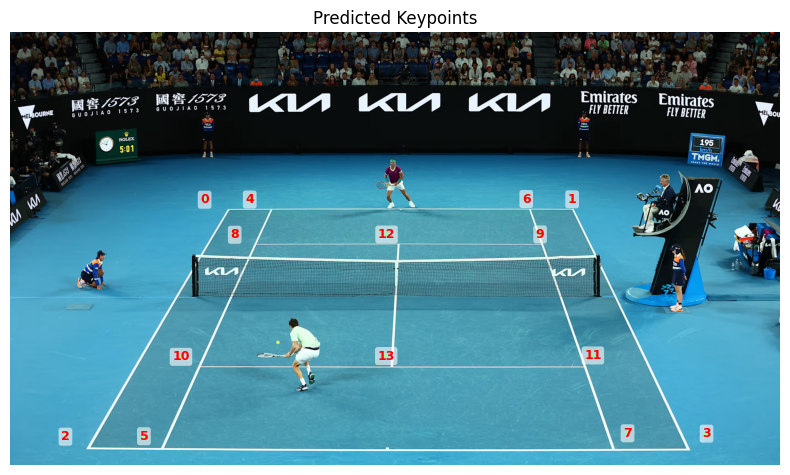

In [52]:
# Load the best model
model = models.resnet50()
model.fc = torch.nn.Linear(model.fc.in_features, 14 * 2)
load_checkpoint("checkpoints/best.pth", model)  # your load_checkpoint function
model = model.to(device)

# Image
#annotated, kps = predict_image(model, "image.png", device)
show_prediction(model, "../data/tennis_match.jpg", device)

In [53]:
predict_video(model, "../data/tennis_match.mp4", "output.mp4", device)

Processing video: 100%|██████████| 224/224 [00:09<00:00, 24.00it/s]


Saved annotated video to: output.mp4


---